In [1]:
# 1. 导入需要的工具
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 2. 读取数据（确保 cs-training.csv 在同一个文件夹）
df = pd.read_csv('cs-training.csv')

# 3. 看一眼数据
print("数据大小:", df.shape)
df.head()

数据大小: (150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
# 4. 删除无意义的列（第一列是行号，没用）
df = df.drop('Unnamed: 0', axis=1)

# 5. 处理年龄 <=0 的异常值（极少）
df = df[df['age'] > 0]

# 6. 处理逾期次数过大的异常（比如 >90）
df = df[df['NumberOfTime30-59DaysPastDueNotWorse'] < 90]
df = df[df['NumberOfTime60-89DaysPastDueNotWorse'] < 90]

# 7. 填补缺失值（用中位数填月收入，用众数填家属数）
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].mode()[0])

print("清洗完成，当前数据形状:", df.shape)

清洗完成，当前数据形状: (149730, 11)


In [3]:
print("剩余缺失值总数:", df.isnull().sum().sum())

剩余缺失值总数: 0


In [4]:
df['SeriousDlqin2yrs'].value_counts(normalize=True)#查看违约客户的占比

SeriousDlqin2yrs
0    0.934021
1    0.065979
Name: proportion, dtype: float64

In [5]:
import matplotlib.pyplot as plt

# 设置中文字体（Windows 系统用 SimHei 或 Microsoft YaHei）
plt.rcParams['font.sans-serif'] = ['SimHei']   # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False     # 用来正常显示负号

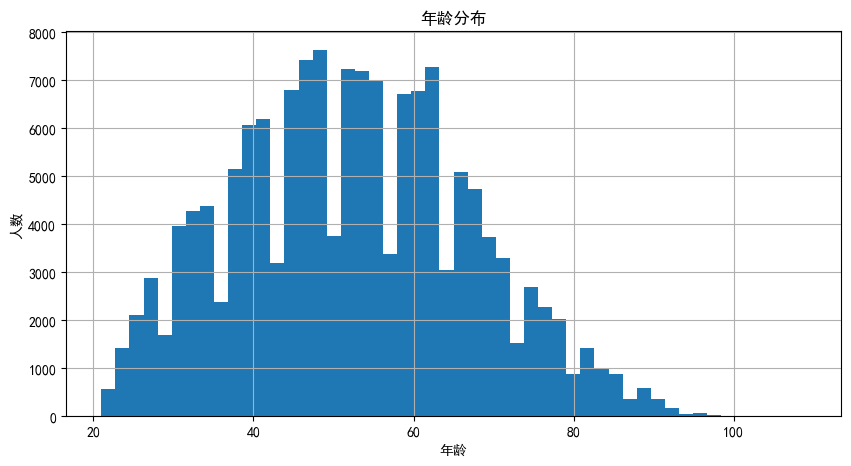

In [6]:
df['age'].hist(bins=50, figsize=(10,5))
plt.title('年龄分布')
plt.xlabel('年龄')
plt.ylabel('人数')
plt.show()

In [7]:
# 查看当前环境配置
import sys
import os

print("当前Python路径：", sys.executable)
print("当前工作目录：", os.getcwd())
print("系统路径：", sys.path[:5])

当前Python路径： D:\Anaconda\python.exe
当前工作目录： D:\学习\credit_scorecard
系统路径： ['D:\\Anaconda\\python313.zip', 'D:\\Anaconda\\DLLs', 'D:\\Anaconda\\Lib', 'D:\\Anaconda', '']


In [8]:
# 主动将包安装到当前Jupyter环境
import sys
!{sys.executable} -m pip install scorecardpy

Defaulting to user installation because normal site-packages is not writeable


In [9]:
# 安装 scorecardpy（如果没装过）
!pip install scorecardpy -q

import scorecardpy as sc
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
print("scorecardpy 版本:", sc.__version__)

C:\Users\10133\AppData\Roaming\Python\Python313\site-packages\scorecardpy\germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


scorecardpy 版本: 0.1.9.7


In [10]:
from sklearn.model_selection import train_test_split#将数据集随机拆分成训练集和测试集。

# 拆分数据集（70% 训练，30% 测试），保持目标变量分布一致
train, test = train_test_split(df, test_size=0.3, random_state=42, stratify=df['SeriousDlqin2yrs'])

print(f"训练集大小: {train.shape}")
print(f"测试集大小: {test.shape}")

训练集大小: (104811, 11)
测试集大小: (44919, 11)


In [11]:
excluded = ['SeriousDlqin2yrs']
features = [col for col in train.columns if col not in excluded]

bins = sc.woebin(train, y='SeriousDlqin2yrs', x=features, 
                 bin_num_limit=5, method='tree', 
                 positive='bad|1', no_cores=1)

print(bins['age'])
print(bins['RevolvingUtilizationOfUnsecuredLines'])

[INFO] creating woe binning ...
  variable          bin  count  count_distr   good   bad   badprob       woe  \
0      age  [-inf,44.0)  30980     0.295580  27942  3038  0.098063  0.431281   
1      age  [44.0,58.0)  35237     0.336196  32652  2585  0.073360  0.114032   
2      age  [58.0,68.0)  21991     0.209816  21062   929  0.042245 -0.470904   
3      age   [68.0,inf)  16603     0.158409  16240   363  0.021864 -1.150617   

     bin_iv  total_iv breaks  is_special_values  
0  0.066378  0.239497   44.0              False  
1  0.004594  0.239497   58.0              False  
2  0.038050  0.239497   68.0              False  
3  0.130475  0.239497    inf              False  
                               variable         bin  count  count_distr  \
0  RevolvingUtilizationOfUnsecuredLines  [-inf,0.2)  57247     0.546193   
1  RevolvingUtilizationOfUnsecuredLines   [0.2,0.5)  18804     0.179409   
2  RevolvingUtilizationOfUnsecuredLines   [0.5,0.8)  11299     0.107804   
3  RevolvingUtili

In [12]:
cond_high_risk= (df['age'] < 44) & (df['RevolvingUtilizationOfUnsecuredLines'] > 0.8)
subset = df[cond_high_risk]
if len(subset) > 0:
    bad_rate = subset['SeriousDlqin2yrs'].mean()
    print(f"该客群违约率: {bad_rate:.4f}")
    print(f"是整体平均的 {bad_rate/0.066:.1f} 倍")
else:
    print("样本不足")

该客群违约率: 0.2312
是整体平均的 3.5 倍


In [13]:
print(bins['MonthlyIncome'])
print(bins['NumberOfTime30-59DaysPastDueNotWorse'])

cond_low_risk = (df['MonthlyIncome'] > 100000) & (df['NumberOfTime30-59DaysPastDueNotWorse'] == 0)
bad_rate = df[cond_low_risk]['SeriousDlqin2yrs'].mean()
print(f"该客群违约概率: {bad_rate:.4f}")

        variable               bin  count  count_distr   good   bad   badprob  \
0  MonthlyIncome     [-inf,5000.0)  36994     0.352959  33844  3150  0.085149   
1  MonthlyIncome   [5000.0,7500.0)  42126     0.401923  39559  2567  0.060936   
2  MonthlyIncome  [7500.0,10000.0)  11884     0.113385  11254   630  0.053012   
3  MonthlyIncome     [10000.0,inf)  13807     0.131732  13239   568  0.041139   

        woe    bin_iv  total_iv   breaks  is_special_values  
0  0.275853  0.030294  0.065102   5000.0              False  
1 -0.084843  0.002789  0.065102   7500.0              False  
2 -0.232546  0.005547  0.065102  10000.0              False  
3 -0.498588  0.026473  0.065102      inf              False  
                               variable         bin  count  count_distr  \
0  NumberOfTime30-59DaysPastDueNotWorse  [-inf,1.0)  88181     0.841333   
1  NumberOfTime30-59DaysPastDueNotWorse   [1.0,2.0)  11246     0.107298   
2  NumberOfTime30-59DaysPastDueNotWorse   [2.0,inf)   5384 

## 业务策略建议

基于模型分箱结果，提出以下风控策略：

1. **高风险客群拒绝/降额**：
   - 条件：年龄 < 44 且 可用额度使用率 > 0.8
   - 理由：该客群违约概率为 23%，是平均水平的 3.5 倍。
   - 建议：根据该客群的高风险特征，建议将授信额度控制在普通客户额度的 30% 以内，例如不超过 5000 元。

2. **低风险客群提额**：
   - 条件：月收入 > 50000 且 过去无逾期记录（逾期次数 = 0）
   - 理由：该客群违约概率仅为 3.4%，信用极好。
   - 建议：建议将额度提升至普通客户的 1.5 倍，例如 15 万元，并可给予利率优惠。

                               variable  total_iv
0  RevolvingUtilizationOfUnsecuredLines  1.062549
6               NumberOfTimes90DaysLate  0.808117
2  NumberOfTime30-59DaysPastDueNotWorse  0.731906
1                                   age  0.239497
3                             DebtRatio  0.078490
4                         MonthlyIncome  0.065102
5       NumberOfOpenCreditLinesAndLoans  0.054966
7          NumberRealEstateLoansOrLines  0.045444
9                    NumberOfDependents  0.033739
8  NumberOfTime60-89DaysPastDueNotWorse  0.000000


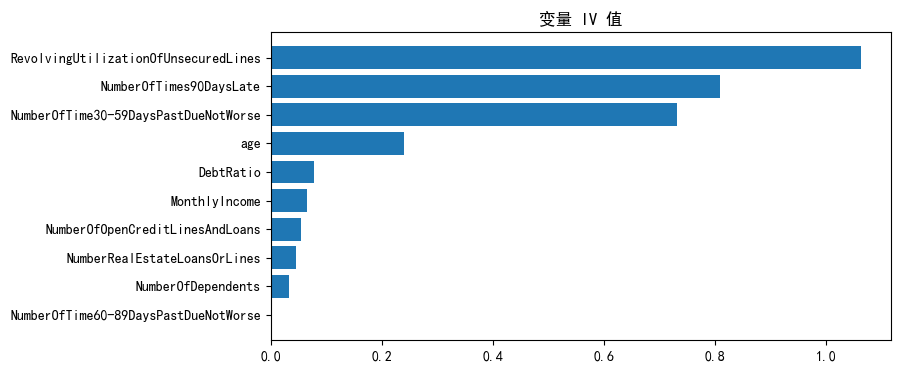

In [14]:
# 手动从 bins 字典中提取每个变量的总 IV
iv_list = []
for var_name, var_bin in bins.items():
    # var_bin 是一个 DataFrame，其中 'total_iv' 列每行都一样，取第一个值即可
    total_iv = var_bin['total_iv'].iloc[0]
    iv_list.append((var_name, total_iv))#把变量名和它的 IV 值作为一个元组追加到 iv_list 中。

iv_df = pd.DataFrame(iv_list, columns=['variable', 'total_iv'])#生成数据表
iv_df = iv_df.sort_values('total_iv', ascending=False)#按照total_iv降序排序

print(iv_df)

# 画图
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.barh(iv_df['variable'], iv_df['total_iv'])
plt.title('变量 IV 值')
plt.gca().invert_yaxis()
plt.show()

In [15]:
# 对训练集和测试集进行 WOE 转换
train_woe = sc.woebin_ply(train, bins)
test_woe = sc.woebin_ply(test, bins)

print("WOE转换后的训练集形状:", train_woe.shape)
train_woe.head()

[INFO] converting into woe values ...
[INFO] converting into woe values ...
WOE转换后的训练集形状: (104811, 11)


,SeriousDlqin2yrs,NumberRealEstateLoansOrLines_woe,RevolvingUtilizationOfUnsecuredLines_woe,age_woe,NumberOfOpenCreditLinesAndLoans_woe,MonthlyIncome_woe,NumberOfTime60-89DaysPastDueNotWorse_woe,NumberOfDependents_woe,DebtRatio_woe,NumberOfTime30-59DaysPastDueNotWorse_woe,NumberOfTimes90DaysLate_woe
38318,0,0.214863,1.314271,0.114032,0.168372,-0.084843,0.0,0.339201,-0.175473,-0.536213,-0.376583
44461,1,-0.225540,0.532161,0.431281,0.168372,-0.084843,0.0,-0.154057,0.320282,1.905066,2.289771
59411,0,0.244678,-1.236221,-0.470904,-0.100080,-0.498588,0.0,-0.154057,-0.175473,0.912889,-0.376583
83769,1,-0.174932,0.532161,0.114032,-0.100080,-0.498588,0.0,-0.154057,0.060581,0.912889,-0.376583
35044,0,0.214863,-1.236221,-1.150617,-0.100080,0.275853,0.0,0.160617,-0.175473,-0.536213,-0.376583


In [16]:
from sklearn.linear_model import LogisticRegression

# 获取特征列名（排除目标变量）
x_cols = [col for col in train_woe.columns if col != 'SeriousDlqin2yrs']

# 将数据转换为 float 类型，避免潜在的数据类型问题
X_train = train_woe[x_cols].astype(float)
y_train = train_woe['SeriousDlqin2yrs'].astype(float)
X_test = test_woe[x_cols].astype(float)
y_test = test_woe['SeriousDlqin2yrs'].astype(float)

# 创建逻辑回归模型（使用默认参数，更稳定）
lr = LogisticRegression(max_iter=1000, random_state=42)

# 训练模型
lr.fit(X_train, y_train)

# 预测概率
train_pred = lr.predict_proba(X_train)[:, 1]
test_pred = lr.predict_proba(X_test)[:, 1]

print("建模完成")

建模完成


In [17]:
from sklearn.metrics import roc_auc_score, roc_curve

# AUC
train_auc = roc_auc_score(y_train, train_pred)
test_auc = roc_auc_score(y_test, test_pred)
print(f"训练集 AUC: {train_auc:.4f}")
print(f"测试集 AUC: {test_auc:.4f}")

# KS 值
def ks(y_true, y_pred):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    return max(tpr - fpr)

train_ks = ks(y_train, train_pred)
test_ks = ks(y_test, test_pred)
print(f"训练集 KS: {train_ks:.4f}")
print(f"测试集 KS: {test_ks:.4f}")

训练集 AUC: 0.8494
测试集 AUC: 0.8478
训练集 KS: 0.5502
测试集 KS: 0.5398


In [18]:
from sklearn.ensemble import RandomForestClassifier

# 随机森林模型
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# 预测概率
rf_train_pred = rf.predict_proba(X_train)[:, 1]
rf_test_pred = rf.predict_proba(X_test)[:, 1]

# 评估
from sklearn.metrics import roc_auc_score
rf_train_auc = roc_auc_score(y_train, rf_train_pred)
rf_test_auc = roc_auc_score(y_test, rf_test_pred)
print(f"随机森林 训练集 AUC: {rf_train_auc:.4f}")
print(f"随机森林 测试集 AUC: {rf_test_auc:.4f}")

随机森林 训练集 AUC: 0.8504
随机森林 测试集 AUC: 0.8468


In [19]:
# 评分卡刻度转换（假设你已经有 bins, lr, x_cols）
card = sc.scorecard(bins, lr, x_cols, points0=600, odds0=0.1, pdo=50)#将逻辑回归模型转换为标准评分卡
print(card['age'])   # 查看年龄评分卡

# 对训练集和测试集打分
train_score = sc.scorecard_ply(train, card)
test_score = sc.scorecard_ply(test, card)

print(train_score[['score']].head())
print(test_score[['score']].head())

  variable          bin  points
4      age  [-inf,44.0)   -14.0
5      age  [44.0,58.0)    -4.0
6      age  [58.0,68.0)    15.0
7      age   [68.0,inf)    38.0
       score
38318  597.0
44461  391.0
59411  679.0
83769  584.0
35044  756.0
        score
113210  745.0
59458   657.0
111106  763.0
89016   665.0
13655   712.0


In [20]:
def calculate_psi(expected, actual, bins=10):#将分数范围划分为 10 个等频区间（按分位数切分）
    boundaries = np.percentile(expected, np.linspace(0, 100, bins+1))
# 然后对 actual 也使用 boundaries 进行分箱
    psi = 0
    n_exp = len(expected)
    n_act = len(actual)
    #遍历每个区间
    for i in range(len(boundaries) - 1):
        lower = boundaries[i]
        upper = boundaries[i+1]
        # 处理最后一个区间包含右端点，其他区间左闭右开
        if i == len(boundaries) - 2:
            exp_count = np.sum((expected >= lower) & (expected <= upper))
            act_count = np.sum((actual >= lower) & (actual <= upper))
        else:
            exp_count = np.sum((expected >= lower) & (expected < upper))
            act_count = np.sum((actual >= lower) & (actual < upper))
        
        exp_pct = exp_count / n_exp
        act_pct = act_count / n_act
        
        if exp_pct > 0 and act_pct > 0:
            psi += (act_pct - exp_pct) * np.log(act_pct / exp_pct)
    
    return psi

psi_value = calculate_psi(train_score['score'], test_score['score'])
print(f"PSI: {psi_value:.4f}")

PSI: 0.0004
